In [ ]:
#data_loader
import pandas as pd
def load_csv(filepath: str):

    try:
        df = pd.read_csv(filepath)
        print(f"CSV файл {filepath} загружен.")
        return df
    except Exception as e:
        print(f"Ошибка при загрузке CSV: {e}")
        return None

In [1]:
#main
import loader as ld
import processing as pr
df = ld.load_csv('/content/Employee_HR.csv')

#Data analysis
pr.info(df)



CSV файл /content/Employee_HR.csv загружен.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   EmpId                 14999 non-null  int64  
 1   Satisfaction          14999 non-null  float64
 2   Evaluation            14999 non-null  float64
 3   number_of_projects    14999 non-null  int64  
 4   average_montly_hours  14999 non-null  int64  
 5   time_spent_company    14999 non-null  int64  
 6   work_accident         14999 non-null  int64  
 7   Promotion             14999 non-null  int64  
 8   Department            14999 non-null  object 
 9   Salary_INR            14999 non-null  int64  
 10  Churn                 14999 non-null  int64  
dtypes: float64(2), int64(8), object(1)
memory usage: 1.3+ MB


In [2]:
#Пропущенные значения
pr.count_missing(df)


,0
EmpId,0
Satisfaction,0
Evaluation,0
number_of_projects,0
average_montly_hours,0
time_spent_company,0
work_accident,0
Promotion,0
Department,0
Salary_INR,0


In [3]:
#Классификатор CatBoost
!pip install catboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.3 MB/s eta 0:00:00


In [4]:
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

X = df.drop(['EmpId', 'Churn'], axis=1)
y = df['Churn']

encoder = LabelEncoder()
X['Department'] = encoder.fit_transform(X['Department'])

#Нормализация среднее кол-во рабочих часов в месяц и условная зарплата
scaler = MinMaxScaler()
X['average_montly_hours'] = scaler.fit_transform(X[['average_montly_hours']])
X['Salary_INR'] = scaler.fit_transform(X[['Salary_INR']])

# Разделение данных на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Создание и обучение классификатора CatBoost
clf = CatBoostClassifier(iterations=100, learning_rate=0.1, depth=3, random_state=42, verbose=0)
clf.fit(X_train, y_train)

# Прогнозирование и оценка точности
y_pred = clf.predict(X_test)

# Вывод метрик классификации
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print(f'Accuracy: {accuracy:.4f}')
print('Classification Report:')
print(report)

Confusion Matrix:
[[2264   30]
 [  66  640]]
Accuracy: 0.9680
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      2294
           1       0.96      0.91      0.93       706

    accuracy                           0.97      3000
   macro avg       0.96      0.95      0.95      3000
weighted avg       0.97      0.97      0.97      3000



In [17]:
# Классификатор градиентного бустинга
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split


# Создание модели Gradient Boosting Classifier
gb_classifier = GradientBoostingClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)

# Обучение модели на обучающем наборе данных
gb_classifier.fit(X_train, y_train)

# Предсказание классов на тестовом наборе данных
y_pred = gb_classifier.predict(X_test)

# Вывод метрик классификации
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print(f'Accuracy: {accuracy:.4f}')
print('Classification Report:')
print(report)


Confusion Matrix:
[[2267   27]
 [  51  655]]
Accuracy: 0.9740
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      2294
           1       0.96      0.93      0.94       706

    accuracy                           0.97      3000
   macro avg       0.97      0.96      0.96      3000
weighted avg       0.97      0.97      0.97      3000



In [18]:
#Классификатор K Neighbors
from sklearn.neighbors import KNeighborsClassifier

# Создание и обучение модели K Neighbors
knn = KNeighborsClassifier(n_neighbors=3)  # Задаем количество соседей (K=3)
knn.fit(X_train, y_train)

# Предсказание на тестовом наборе
y_pred = knn.predict(X_test)

# Вывод метрик классификации
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print(f'Accuracy: {accuracy:.4f}')
print('Classification Report:')
print(report)

Confusion Matrix:
[[2218   76]
 [  43  663]]
Accuracy: 0.9603
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.97      2294
           1       0.90      0.94      0.92       706

    accuracy                           0.96      3000
   macro avg       0.94      0.95      0.95      3000
weighted avg       0.96      0.96      0.96      3000



In [19]:
#Классификатор Random Forest
from sklearn.ensemble import RandomForestClassifier

# Создание и обучение модели
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Предсказание на тестовом наборе
y_pred = knn.predict(X_test)

# Вывод метрик классификации
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print(f'Accuracy: {accuracy:.4f}')
print('Classification Report:')
print(report)

Confusion Matrix:
[[2218   76]
 [  43  663]]
Accuracy: 0.9603
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.97      2294
           1       0.90      0.94      0.92       706

    accuracy                           0.96      3000
   macro avg       0.94      0.95      0.95      3000
weighted avg       0.96      0.96      0.96      3000



In [20]:
#Классификаор SVM
from sklearn.svm import SVC
# Создание и обучение модели SVM
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_model.fit(X_train, y_train)

# Предсказание и отчет о классификации
y_pred = svm_model.predict(X_test)

# Вывод метрик классификации
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print(f'Accuracy: {accuracy:.4f}')
print('Classification Report:')
print(report)

Confusion Matrix:
[[2208   86]
 [  75  631]]
Accuracy: 0.9463
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.96      0.96      2294
           1       0.88      0.89      0.89       706

    accuracy                           0.95      3000
   macro avg       0.92      0.93      0.93      3000
weighted avg       0.95      0.95      0.95      3000



In [21]:
#Классификатор LogisticRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
model = LogisticRegression(C=1.0, solver='lbfgs')
model.fit(X_train, y_train)

# Предсказание и отчет о классификации
y_pred = model.predict(X_test)

# Вывод метрик классификации
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print(f'Accuracy: {accuracy:.4f}')
print('Classification Report:')
print(report)

Confusion Matrix:
[[2127  167]
 [ 519  187]]
Accuracy: 0.7713
Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.93      0.86      2294
           1       0.53      0.26      0.35       706

    accuracy                           0.77      3000
   macro avg       0.67      0.60      0.61      3000
weighted avg       0.74      0.77      0.74      3000




Stacking Classifier Accuracy: 0.9877
Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2294
           1       0.99      0.96      0.97       706

    accuracy                           0.99      3000
   macro avg       0.99      0.98      0.98      3000
weighted avg       0.99      0.99      0.99      3000



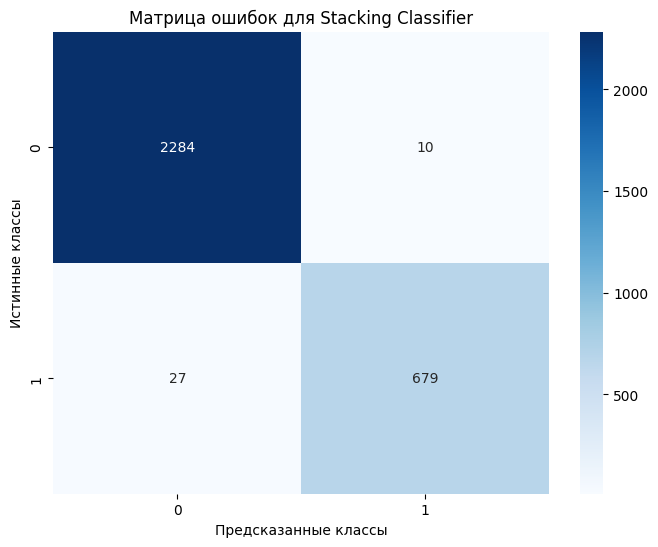

In [22]:
#Многоклассная классификация с использованием StackingClassifier
from sklearn.ensemble import (
    AdaBoostClassifier,
    ExtraTreesClassifier,
    RandomForestClassifier,
    StackingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import numpy as np

# Определение базовых классификаторов
base_classifiers = [
    ('random_forest', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('catboost', CatBoostClassifier(verbose=0, random_state=42)),
    ('extra_trees', ExtraTreesClassifier(random_state=42)),

]
# Определение мета-классификатора
meta_classifier = LogisticRegression(random_state=42, max_iter=1000)

# Создание StackingClassifier
stacking_clf = StackingClassifier(
    estimators=base_classifiers,
    final_estimator=meta_classifier,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1,
    passthrough=False
)
# Обучение StackingClassifier
stacking_clf.fit(X_train, y_train)

# Прогнозирование на тестовых данных
y_pred = stacking_clf.predict(X_test)

# Оценка модели
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f'\nStacking Classifier Accuracy: {accuracy:.4f}')
print('Classification Report:')
print(report)

# Визуализация матрицы ошибок
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y),
            yticklabels=np.unique(y))
plt.xlabel('Предсказанные классы')
plt.ylabel('Истинные классы')
plt.title('Матрица ошибок для Stacking Classifier')
plt.show()